In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FormatStrFormatter

from pbhstat.power_spectrum import PowerSpectrum
from pbhstat.mass_variance import MassVariance
from pbhstat.collapse_stats import PressSchechterModel, PeaksTheoryModel, NonLinearModel
from pbhstat.mass_function import MassFunction
from pbhstat.plot_utils import plot_power_spectrum, plot_mass_variance, plot_mass_function, bounds_utility

In [21]:
# Set up k values
k_values = np.logspace(4, 8, 3000)

# Piecewise power spectrum
ps_piecewise = PowerSpectrum(
    shape='piecewise',
    amplitude=0.01,
    k_star=1e6,
    ng=6,
    nd=6,
    k_values=k_values
)


# Instantiate mass variance with choice of window function and statistics
mv_piecewise = MassVariance(window='realtophat', power_spectrum=ps_piecewise, statistics='nonlinear', cutoff=True)

# Instantiate mass function with same statistics model
mass_function = MassFunction(mass_variance=mv_piecewise, statistics='nonlinear',K=4,vcorr=True,gamma=0.36)

In [22]:
# Evaluate f(M) and f_PBH
m, f_m = mass_function.evaluate(k_values, mpbh_vals=10)

fpbh = mass_function.fpbh(f_m, m)

Evaluating NonLinearModel: 100%|██████████| 10/10 [00:13<00:00,  1.33s/it]


In [ ]:
bounds_utility(m, f_m, '/Documents/PBHbounds/')

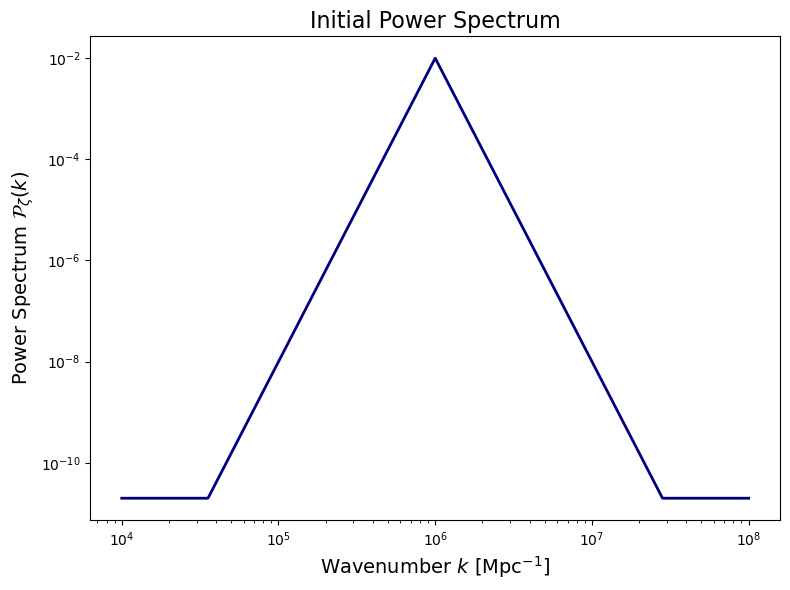

In [23]:
# Plot power spectrum

plot_power_spectrum(k_values, P_k_custom)

# Plot mass variance

# Define R values
R_values = 1/k_values

# Evaluate mass variance at k_values
sigma_custom = mv_custom.evaluate(k_values)

plot_mass_variance(R_values, sigma_custom)

# Plot mass function

plot_mass_function(m, f_m, fpbh_val=fpbh)